# Algorithmic Fairness 2

| | |
|---|---|
| **Name** | Om Dipak Patil |
| **GH Number** | GH1044372 |
| **Module** | M515A Ethical Issues for AI |
| **Assignment** | Assignment 2: Algorithmic Fairness 2 |

---

**Objective:** Evaluate whether machine learning models are unfair by calculating relative disadvantage measures across protected groups.  
**Dataset:** UCI Adult Dataset  
**Target Variable:** `Target` (income >50K or <=50K)  
**Sensitive Attributes:** `Sex` (Male / Female) and `Race` (White, Black, Asian-Pac-Islander, Amer-Indian-Eskimo, Other)  
**Models:** Logistic Regression, Random Forest, Decision Tree  
**Fairness Measures:** Disparate Treatment, Disparate Impact, Disparate Mistreatment  


---
## 1. Data Loading

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

In [ ]:
df = pd.read_csv('adult_train.csv')
print('Shape:', df.shape)
print('\nColumns:', df.columns.tolist())
df.head()

Shape: (32561, 15)

Columns: ['Age', 'Workclass', 'fnlwgt', 'Education', 'Education_Num', 'Martial_Status', 'Occupation', 'Relationship', 'Race', 'Sex', 'Capital_Gain', 'Capital_Loss', 'Hours_per_week', 'Country', 'Target']


,Age,Workclass,fnlwgt,Education,Education_Num,Martial_Status,Occupation,Relationship,Race,Sex,Capital_Gain,Capital_Loss,Hours_per_week,Country,Target
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [ ]:
print('Target values:  ', df['Target'].astype(str).str.strip().unique())
print('Sex values:     ', df['Sex'].astype(str).str.strip().unique())
print('Race values:    ', df['Race'].astype(str).str.strip().unique())

Target values:   <StringArray>
['<=50K', '>50K']
Length: 2, dtype: str
Sex values:      <StringArray>
['Male', 'Female']
Length: 2, dtype: str
Race values:     <StringArray>
['White', 'Black', 'Asian-Pac-Islander', 'Amer-Indian-Eskimo', 'Other']
Length: 5, dtype: str


---
## 2. Data Cleaning

In [ ]:
# Strip leading/trailing whitespace from all columns
for c in df.columns:
    df[c] = df[c].astype(str).str.strip()

# Replace 'nan' strings back to NaN and drop
df.replace('nan', np.nan, inplace=True)
print('Missing values per column:')
print(df.isnull().sum())

rows_before = df.shape[0]
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)
print(f'\nRows before cleaning: {rows_before}')
print(f'Rows after  cleaning: {df.shape[0]}')
print(f'Rows removed:         {rows_before - df.shape[0]}')

Missing values per column:


Age                  0
Workclass         1836
fnlwgt               0
Education            0
Education_Num        0
Martial_Status       0
Occupation        1843
Relationship         0
Race                 0
Sex                  0
Capital_Gain         0
Capital_Loss         0
Hours_per_week       0
Country            583
Target               0
dtype: int64

Rows before cleaning: 32561
Rows after  cleaning: 30162
Rows removed:         2399


In [ ]:
# Target class distribution
print('Target distribution:')
print(df['Target'].value_counts())
print()
print('Sex distribution:')
print(df['Sex'].value_counts())
print()
print('Race distribution:')
print(df['Race'].value_counts())

Target distribution:
Target
<=50K    22654
>50K      7508
Name: count, dtype: int64

Sex distribution:
Sex
Male      20380
Female     9782
Name: count, dtype: int64

Race distribution:
Race
White                 25933
Black                  2817
Asian-Pac-Islander      895
Amer-Indian-Eskimo      286
Other                   231
Name: count, dtype: int64


---
## 3. Data Preprocessing

In [ ]:
sex_raw  = df['Sex'].copy()
race_raw = df['Race'].copy()
for c in df.columns:
    try:
        df[c] = pd.to_numeric(df[c])
    except ValueError:
        le = LabelEncoder()
        df[c] = le.fit_transform(df[c].astype(str)).astype(int)

print('All columns encoded. dtypes:')
print(df.dtypes)

All columns encoded. dtypes:
Age               int64
Workclass         int64
fnlwgt            int64
Education         int64
Education_Num     int64
Martial_Status    int64
Occupation        int64
Relationship      int64
Race              int64
Sex               int64
Capital_Gain      int64
Capital_Loss      int64
Hours_per_week    int64
Country           int64
Target            int64
dtype: object


In [ ]:
X = df.drop(columns=['Target']).astype(float)
y = df['Target'].astype(int)
# 80/20 stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
# Scale features for Logistic Regression
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)
# Align sensitive attributes to test set index
sex_test  = sex_raw.loc[X_test.index].reset_index(drop=True)
race_test = race_raw.loc[X_test.index].reset_index(drop=True)
y_test_r  = y_test.reset_index(drop=True)

print(f'Train size: {X_train.shape[0]}  |  Test size: {X_test.shape[0]}')
print(f'Positive class (>50K) in test: {y_test_r.sum()} / {len(y_test_r)} ({y_test_r.mean():.2%})')

Train size: 24129  |  Test size: 6033
Positive class (>50K) in test: 1502 / 6033 (24.90%)


---
## 4. Model Training

In [ ]:
# Initialise 3 classifiers
lr = LogisticRegression(max_iter=2000, solver='saga', random_state=42)
rf = RandomForestClassifier(n_estimators=100, random_state=42)
dt = DecisionTreeClassifier(max_depth=10, random_state=42)
# Train — LR uses scaled data; RF and DT use raw data
lr.fit(X_train_s, y_train)
rf.fit(X_train,   y_train)
dt.fit(X_train,   y_train)
# Predictions
pred_lr = lr.predict(X_test_s)
pred_rf = rf.predict(X_test)
pred_dt = dt.predict(X_test)
# Accuracy summary
acc_table = pd.DataFrame({
    'Model':    ['Logistic Regression', 'Random Forest', 'Decision Tree'],
    'Accuracy': [
        round(accuracy_score(y_test, pred_lr), 4),
        round(accuracy_score(y_test, pred_rf), 4),
        round(accuracy_score(y_test, pred_dt), 4),
    ]
})
print('Model Accuracy:')
acc_table

Model Accuracy:


,Model,Accuracy
0,Logistic Regression,0.8177
1,Random Forest,0.8541
2,Decision Tree,0.8510


---
## 5. Group Partitioning

In [ ]:
print('Test set group sizes:\n')
print('--- Sex ---')
print(sex_test.value_counts().to_string())
print('\n--- Race ---')
print(race_test.value_counts().to_string())

Test set group sizes:

--- Sex ---
Sex
Male      4065
Female    1968

--- Race ---
Race
White                 5186
Black                  559
Asian-Pac-Islander     186
Amer-Indian-Eskimo      64
Other                   38


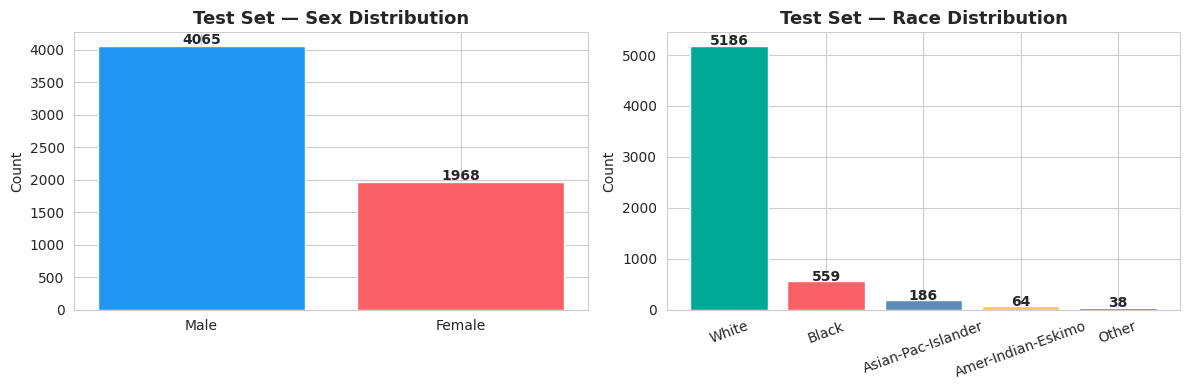

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sex_counts = sex_test.value_counts()
axes[0].bar(sex_counts.index, sex_counts.values, color=['#2196F3','#F96167'])
axes[0].set_title('Test Set — Sex Distribution', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(sex_counts.values):
    axes[0].text(i, v + 30, str(v), ha='center', fontweight='bold')

race_counts = race_test.value_counts()
axes[1].bar(race_counts.index, race_counts.values,
            color=['#00A896','#F96167','#5B8DB8','#F9C74F','#6B3FA0'])
axes[1].set_title('Test Set — Race Distribution', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=20)
for i, v in enumerate(race_counts.values):
    axes[1].text(i, v + 10, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

---
## 6. Fairness Helper Function

In [ ]:
def group_metrics(y_true, y_pred, group_col):
    """
    For each group in group_col, compute:
      - Positive prediction rate
      - FPR = FP / (FP + TN)
      - FNR = FN / (FN + TP)
    """
    rows = []
    for g in sorted(group_col.unique()):
        mask = group_col == g
        yt   = np.array(y_true[mask])
        yp   = np.array(y_pred[mask])
        pos_rate = yp.mean()
        tn, fp, fn, tp = confusion_matrix(yt, yp, labels=[0, 1]).ravel()
        fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
        fnr = fn / (fn + tp) if (fn + tp) > 0 else 0
        rows.append({
            'Group':    g,
            'N':        int(mask.sum()),
            'Pos_Rate': round(float(pos_rate), 4),
            'FPR':      round(float(fpr), 4),
            'FNR':      round(float(fnr), 4)
        })
    return pd.DataFrame(rows).set_index('Group')

---
## 7. Disparate Treatment

**Definition:** The model treats individuals differently based on their protected attribute — measured by the gap in positive prediction rates between groups.

$$\text{Disparate Treatment} = P(\hat{y}=1 \mid \text{privileged}) - P(\hat{y}=1 \mid \text{unprivileged})$$

- Privileged group: **Male** (sex), **White** (race)
- A larger positive gap indicates greater disparate treatment
- **Threshold:** Gap > 0.05 → Unfair

In [ ]:
models_preds = {
    'Logistic Regression': pred_lr,
    'Random Forest':       pred_rf,
    'Decision Tree':       pred_dt,
}

print('=' * 60)
print('DISPARATE TREATMENT — SEX')
print('=' * 60)
dt_sex_rows = []
for mname, preds in models_preds.items():
    gm = group_metrics(y_test_r, preds, sex_test)
    male_rate   = gm.loc['Male',   'Pos_Rate']
    female_rate = gm.loc['Female', 'Pos_Rate']
    gap = round(male_rate - female_rate, 4)
    verdict = 'UNFAIR' if abs(gap) > 0.05 else 'FAIR'
    dt_sex_rows.append({
        'Model': mname,
        'Male Pos Rate':   male_rate,
        'Female Pos Rate': female_rate,
        'Gap (M - F)':     gap,
        'Verdict':         verdict
    })

dt_sex_df = pd.DataFrame(dt_sex_rows)
print(dt_sex_df.to_string(index=False))

DISPARATE TREATMENT — SEX
              Model  Male Pos Rate  Female Pos Rate  Gap (M - F) Verdict
Logistic Regression         0.2123           0.0381       0.1742  UNFAIR
      Random Forest         0.2674           0.0971       0.1703  UNFAIR
      Decision Tree         0.2487           0.1006       0.1481  UNFAIR


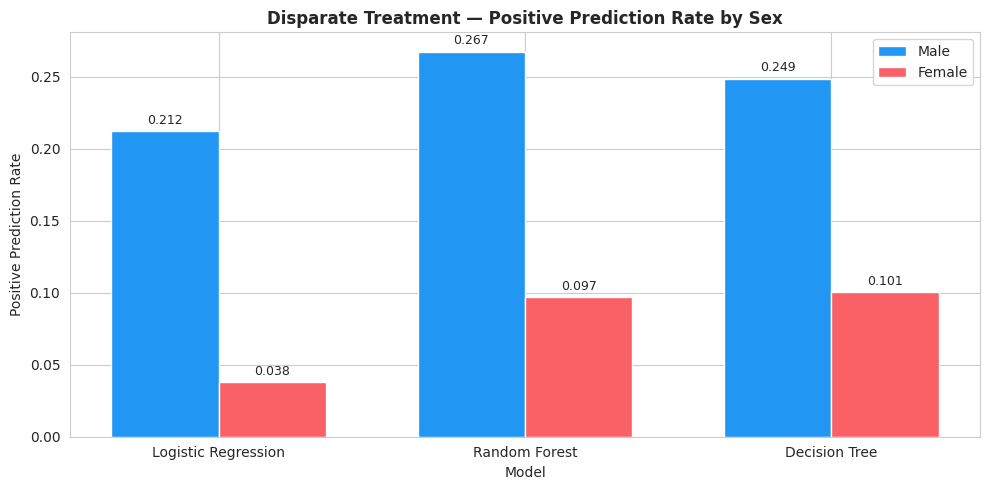

In [ ]:
model_names = ['Logistic Regression', 'Random Forest', 'Decision Tree']
x = np.arange(len(model_names))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
male_rates   = dt_sex_df['Male Pos Rate'].values
female_rates = dt_sex_df['Female Pos Rate'].values

bars1 = ax.bar(x - width/2, male_rates,   width, label='Male',   color='#2196F3')
bars2 = ax.bar(x + width/2, female_rates, width, label='Female', color='#F96167')

ax.set_xlabel('Model')
ax.set_ylabel('Positive Prediction Rate')
ax.set_title('Disparate Treatment — Positive Prediction Rate by Sex', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(model_names)
ax.legend()
for bar in bars1: ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005, f'{bar.get_height():.3f}', ha='center', fontsize=9)
for bar in bars2: ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005, f'{bar.get_height():.3f}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

In [ ]:
print('=' * 70)
print('DISPARATE TREATMENT — RACE')
print('=' * 70)
for mname, preds in models_preds.items():
    gm = group_metrics(y_test_r, preds, race_test)
    white_rate = gm.loc['White', 'Pos_Rate']
    print(f'\n  Model: {mname}')
    display_df = gm[['N','Pos_Rate']].copy()
    display_df['Gap vs White'] = (display_df['Pos_Rate'] - white_rate).round(4)
    display_df['Verdict'] = display_df['Gap vs White'].apply(
        lambda g: 'UNFAIR' if abs(g) > 0.05 and display_df.index[display_df['Gap vs White']==g][0] != 'White' else ('REF' if abs(g)==0 else 'FAIR')
    )
    print(display_df.to_string())

DISPARATE TREATMENT — RACE

  Model: Logistic Regression
                       N  Pos_Rate  Gap vs White Verdict
Group                                                   
Amer-Indian-Eskimo    64    0.0156       -0.1533  UNFAIR
Asian-Pac-Islander   186    0.1452       -0.0237    FAIR
Black                559    0.0572       -0.1117  UNFAIR
Other                 38    0.0526       -0.1163  UNFAIR
White               5186    0.1689        0.0000     REF

  Model: Random Forest
                       N  Pos_Rate  Gap vs White Verdict
Group                                                   
Amer-Indian-Eskimo    64    0.0312       -0.1965  UNFAIR
Asian-Pac-Islander   186    0.2312        0.0035    FAIR
Black                559    0.0877       -0.1400  UNFAIR
Other                 38    0.0789       -0.1488  UNFAIR
White               5186    0.2277        0.0000     REF

  Model: Decision Tree
                       N  Pos_Rate  Gap vs White Verdict
Group                                   

---
## 8. Disparate Impact

**Definition:** The ratio of the positive prediction rate of the unprivileged group to the privileged group.

$$\text{Disparate Impact} = \frac{P(\hat{y}=1 \mid \text{unprivileged})}{P(\hat{y}=1 \mid \text{privileged})}$$

- **80% Rule (Four-Fifths Rule):** If DI < **0.8** → model is legally and statistically **unfair**
- If DI = 1.0 → perfect parity
- If DI < 0.8 → the unprivileged group receives the favourable outcome at less than 80% the rate of the privileged group

In [ ]:
print('=' * 60)
print('DISPARATE IMPACT — SEX')
print('=' * 60)
di_sex_rows = []
for mname, preds in models_preds.items():
    gm = group_metrics(y_test_r, preds, sex_test)
    male_rate   = gm.loc['Male',   'Pos_Rate']
    female_rate = gm.loc['Female', 'Pos_Rate']
    di = round(female_rate / male_rate, 4) if male_rate > 0 else None
    verdict = 'UNFAIR (DI < 0.8)' if di < 0.8 else 'FAIR'
    di_sex_rows.append({
        'Model':             mname,
        'Male Pos Rate':     male_rate,
        'Female Pos Rate':   female_rate,
        'DI (F/M)':          di,
        'Verdict':           verdict
    })

di_sex_df = pd.DataFrame(di_sex_rows)
print(di_sex_df.to_string(index=False))

DISPARATE IMPACT — SEX
              Model  Male Pos Rate  Female Pos Rate  DI (F/M)           Verdict
Logistic Regression         0.2123           0.0381    0.1795 UNFAIR (DI < 0.8)
      Random Forest         0.2674           0.0971    0.3631 UNFAIR (DI < 0.8)
      Decision Tree         0.2487           0.1006    0.4045 UNFAIR (DI < 0.8)


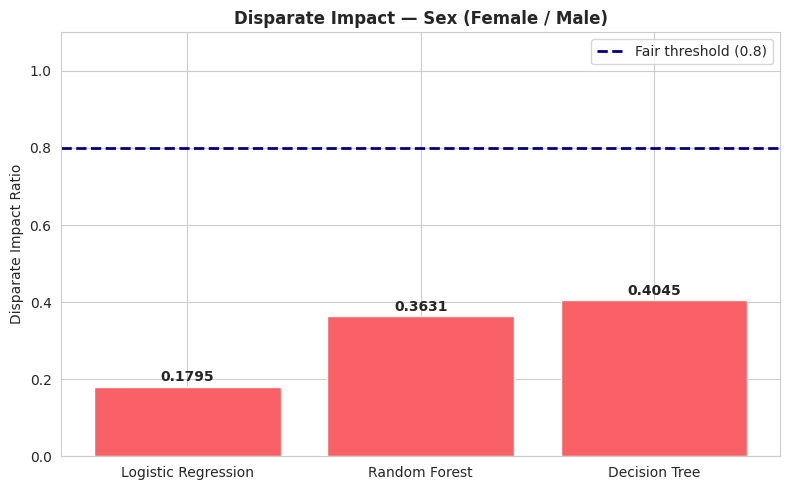

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#F96167' if d < 0.8 else '#00A896' for d in di_sex_df['DI (F/M)']]
bars = ax.bar(di_sex_df['Model'], di_sex_df['DI (F/M)'], color=colors)
ax.axhline(y=0.8, color='navy', linestyle='--', linewidth=2, label='Fair threshold (0.8)')
ax.set_ylabel('Disparate Impact Ratio')
ax.set_title('Disparate Impact — Sex (Female / Male)', fontweight='bold')
ax.legend()
ax.set_ylim(0, 1.1)
for bar in bars:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.015,
            f'{bar.get_height():.4f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
print('=' * 70)
print('DISPARATE IMPACT — RACE (vs White as privileged group)')
print('=' * 70)
di_race_all = []
for mname, preds in models_preds.items():
    gm = group_metrics(y_test_r, preds, race_test)
    white_rate = gm.loc['White', 'Pos_Rate']
    for g in gm.index:
        if g == 'White':
            continue
        di = round(gm.loc[g, 'Pos_Rate'] / white_rate, 4) if white_rate > 0 else None
        verdict = 'UNFAIR' if di < 0.8 else 'FAIR'
        di_race_all.append({'Model': mname, 'Group': g, 'Group Pos Rate': gm.loc[g,'Pos_Rate'],
                            'White Pos Rate': white_rate, 'DI': di, 'Verdict': verdict})

di_race_df = pd.DataFrame(di_race_all)
print(di_race_df.to_string(index=False))

DISPARATE IMPACT — RACE (vs White as privileged group)


              Model              Group  Group Pos Rate  White Pos Rate     DI Verdict
Logistic Regression Amer-Indian-Eskimo          0.0156          0.1689 0.0924  UNFAIR
Logistic Regression Asian-Pac-Islander          0.1452          0.1689 0.8597    FAIR
Logistic Regression              Black          0.0572          0.1689 0.3387  UNFAIR
Logistic Regression              Other          0.0526          0.1689 0.3114  UNFAIR
      Random Forest Amer-Indian-Eskimo          0.0312          0.2277 0.1370  UNFAIR
      Random Forest Asian-Pac-Islander          0.2312          0.2277 1.0154    FAIR
      Random Forest              Black          0.0877          0.2277 0.3852  UNFAIR
      Random Forest              Other          0.0789          0.2277 0.3465  UNFAIR
      Decision Tree Amer-Indian-Eskimo          0.0938          0.2144 0.4375  UNFAIR
      Decision Tree Asian-Pac-Islander          0.2312          0.2144 1.0784    FAIR
      Decision Tree              Black          0.0805

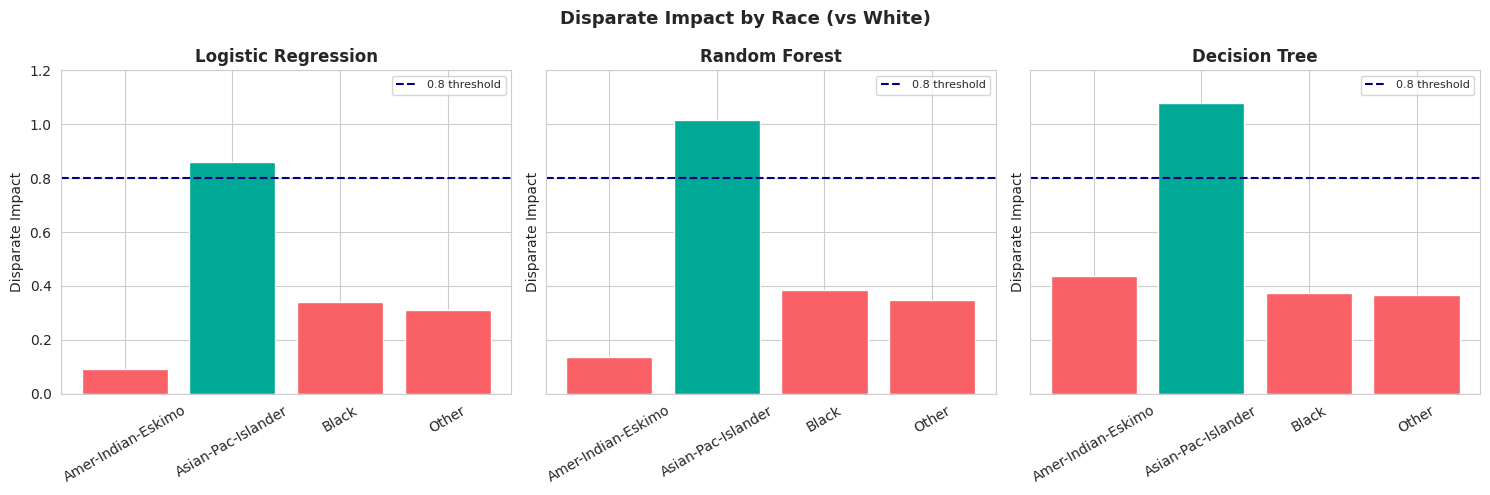

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
for ax, mname in zip(axes, model_names):
    sub = di_race_df[di_race_df['Model'] == mname]
    colors = ['#F96167' if d < 0.8 else '#00A896' for d in sub['DI']]
    ax.bar(sub['Group'], sub['DI'], color=colors)
    ax.axhline(y=0.8, color='navy', linestyle='--', linewidth=1.5, label='0.8 threshold')
    ax.set_title(mname, fontweight='bold')
    ax.set_ylabel('Disparate Impact')
    ax.tick_params(axis='x', rotation=30)
    ax.set_ylim(0, 1.2)
    ax.legend(fontsize=8)
plt.suptitle('Disparate Impact by Race (vs White)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 9. Disparate Mistreatment

**Definition:** The model makes significantly different error rates for different groups.

$$\text{FPR} = \frac{FP}{FP + TN} \quad \text{(wrongly predicts >50K for someone who earns <=50K)}$$

$$\text{FNR} = \frac{FN}{FN + TP} \quad \text{(misses someone who truly earns >50K)}$$

$$\Delta\text{FPR} = \text{FPR}_{privileged} - \text{FPR}_{unprivileged}$$

$$\Delta\text{FNR} = \text{FNR}_{privileged} - \text{FNR}_{unprivileged}$$

- **Threshold:** |ΔFPR| > 0.05 or |ΔFNR| > 0.05 → **Unfair**

In [ ]:
print('=' * 70)
print('DISPARATE MISTREATMENT — SEX')
print('=' * 70)
dm_sex_rows = []
for mname, preds in models_preds.items():
    gm = group_metrics(y_test_r, preds, sex_test)
    fpr_male   = gm.loc['Male',   'FPR']
    fpr_female = gm.loc['Female', 'FPR']
    fnr_male   = gm.loc['Male',   'FNR']
    fnr_female = gm.loc['Female', 'FNR']
    delta_fpr = round(fpr_male - fpr_female, 4)
    delta_fnr = round(fnr_male - fnr_female, 4)
    verdict = 'UNFAIR' if abs(delta_fpr) > 0.05 or abs(delta_fnr) > 0.05 else 'FAIR'
    dm_sex_rows.append({
        'Model':      mname,
        'FPR Male':   fpr_male,
        'FPR Female': fpr_female,
        'ΔFPR':       delta_fpr,
        'FNR Male':   fnr_male,
        'FNR Female': fnr_female,
        'ΔFNR':       delta_fnr,
        'Verdict':    verdict
    })

dm_sex_df = pd.DataFrame(dm_sex_rows)
print(dm_sex_df.to_string(index=False))

DISPARATE MISTREATMENT — SEX
              Model  FPR Male  FPR Female   ΔFPR  FNR Male  FNR Female    ΔFNR Verdict
Logistic Regression    0.0879      0.0127 0.0752    0.5130      0.7745 -0.2615  UNFAIR
      Random Forest    0.1011      0.0260 0.0751    0.3654      0.3787 -0.0133  UNFAIR
      Decision Tree    0.0883      0.0323 0.0560    0.3970      0.3957  0.0013  UNFAIR


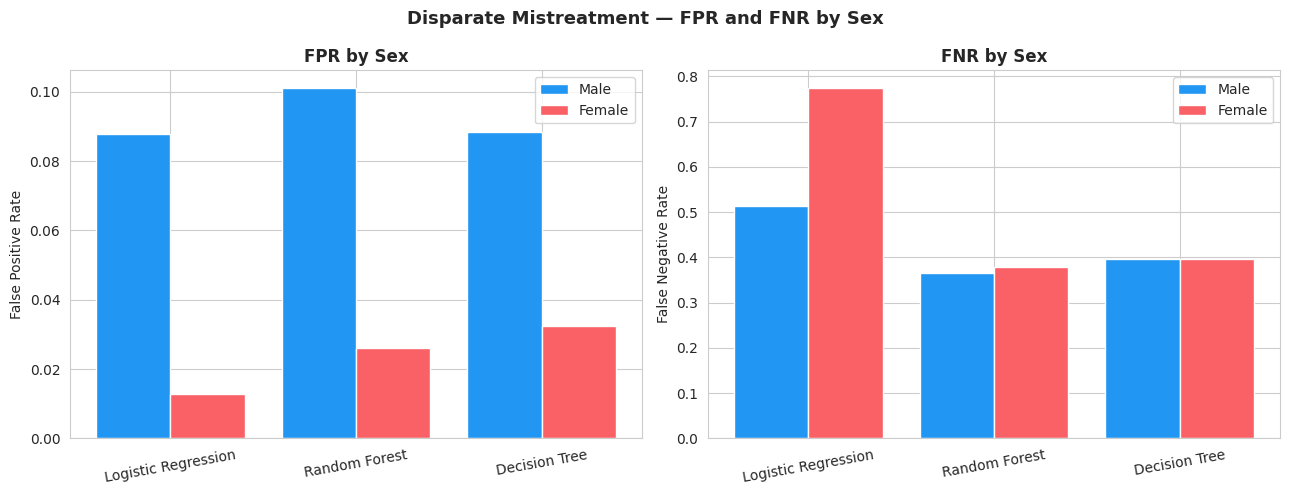

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# FPR comparison
x = np.arange(len(model_names))
axes[0].bar(x - 0.2, dm_sex_df['FPR Male'],   0.4, label='Male',   color='#2196F3')
axes[0].bar(x + 0.2, dm_sex_df['FPR Female'], 0.4, label='Female', color='#F96167')
axes[0].set_title('FPR by Sex', fontweight='bold')
axes[0].set_xticks(x); axes[0].set_xticklabels(model_names, rotation=10)
axes[0].set_ylabel('False Positive Rate'); axes[0].legend()

# FNR comparison
axes[1].bar(x - 0.2, dm_sex_df['FNR Male'],   0.4, label='Male',   color='#2196F3')
axes[1].bar(x + 0.2, dm_sex_df['FNR Female'], 0.4, label='Female', color='#F96167')
axes[1].set_title('FNR by Sex', fontweight='bold')
axes[1].set_xticks(x); axes[1].set_xticklabels(model_names, rotation=10)
axes[1].set_ylabel('False Negative Rate'); axes[1].legend()

plt.suptitle('Disparate Mistreatment — FPR and FNR by Sex', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
print('=' * 70)
print('DISPARATE MISTREATMENT — RACE')
print('=' * 70)
dm_race_all = []
for mname, preds in models_preds.items():
    gm = group_metrics(y_test_r, preds, race_test)
    white_fpr = gm.loc['White', 'FPR']
    white_fnr = gm.loc['White', 'FNR']
    for g in gm.index:
        if g == 'White': continue
        d_fpr = round(gm.loc[g,'FPR'] - white_fpr, 4)
        d_fnr = round(gm.loc[g,'FNR'] - white_fnr, 4)
        verdict = 'UNFAIR' if abs(d_fpr) > 0.05 or abs(d_fnr) > 0.05 else 'FAIR'
        dm_race_all.append({
            'Model': mname, 'Group': g,
            'FPR':   gm.loc[g,'FPR'], 'FPR White': white_fpr, 'ΔFPR': d_fpr,
            'FNR':   gm.loc[g,'FNR'], 'FNR White': white_fnr, 'ΔFNR': d_fnr,
            'Verdict': verdict
        })

dm_race_df = pd.DataFrame(dm_race_all)
print(dm_race_df.to_string(index=False))

DISPARATE MISTREATMENT — RACE
              Model              Group    FPR  FPR White    ΔFPR    FNR  FNR White    ΔFNR Verdict
Logistic Regression Amer-Indian-Eskimo 0.0000     0.0652 -0.0652 0.8333     0.5420  0.2913  UNFAIR
Logistic Regression Asian-Pac-Islander 0.0423     0.0652 -0.0229 0.5227     0.5420 -0.0193    FAIR
Logistic Regression              Black 0.0251     0.0652 -0.0401 0.7500     0.5420  0.2080  UNFAIR
Logistic Regression              Other 0.0286     0.0652 -0.0366 0.6667     0.5420  0.1247  UNFAIR
      Random Forest Amer-Indian-Eskimo 0.0172     0.0802 -0.0630 0.8333     0.3608  0.4725  UNFAIR
      Random Forest Asian-Pac-Islander 0.0845     0.0802  0.0043 0.2955     0.3608 -0.0653  UNFAIR
      Random Forest              Black 0.0167     0.0802 -0.0635 0.4875     0.3608  0.1267  UNFAIR
      Random Forest              Other 0.0286     0.0802 -0.0516 0.3333     0.3608 -0.0275  UNFAIR
      Decision Tree Amer-Indian-Eskimo 0.0517     0.0741 -0.0224 0.5000     0.3

---
## 10. Summary Verdict Table

In [ ]:
summary_rows = []
for mname, preds in models_preds.items():
    gm_sex  = group_metrics(y_test_r, preds, sex_test)
    gm_race = group_metrics(y_test_r, preds, race_test)

    # Sex metrics
    m_rate = gm_sex.loc['Male',   'Pos_Rate']
    f_rate = gm_sex.loc['Female', 'Pos_Rate']
    di_sex = round(f_rate / m_rate, 4)
    dt_gap = round(m_rate - f_rate, 4)
    dfpr_s = round(gm_sex.loc['Male','FPR'] - gm_sex.loc['Female','FPR'], 4)
    dfnr_s = round(gm_sex.loc['Male','FNR'] - gm_sex.loc['Female','FNR'], 4)

    # Race: Black vs White
    w_rate  = gm_race.loc['White', 'Pos_Rate']
    b_rate  = gm_race.loc['Black', 'Pos_Rate']
    di_race = round(b_rate / w_rate, 4)
    dfpr_r  = round(gm_race.loc['Black','FPR'] - gm_race.loc['White','FPR'], 4)
    dfnr_r  = round(gm_race.loc['Black','FNR'] - gm_race.loc['White','FNR'], 4)

    summary_rows.append({
        'Model':           mname,
        'Acc':             round(accuracy_score(y_test, preds), 4),
        # Sex
        'DT Gap(Sex)':     dt_gap,
        'DI Sex':          di_sex,
        'ΔFPR(Sex)':       dfpr_s,
        'ΔFNR(Sex)':       dfnr_s,
        'DT(Sex)':         'UNFAIR' if abs(dt_gap) > 0.05 else 'FAIR',
        'DI(Sex)':         'UNFAIR' if di_sex < 0.8  else 'FAIR',
        'DM(Sex)':         'UNFAIR' if abs(dfpr_s) > 0.05 or abs(dfnr_s) > 0.05 else 'FAIR',
        # Race
        'DT Gap(Race)':    round(w_rate - b_rate, 4),
        'DI Race(B/W)':    di_race,
        'ΔFPR(Race)':      dfpr_r,
        'ΔFNR(Race)':      dfnr_r,
        'DT(Race)':        'UNFAIR' if abs(w_rate - b_rate) > 0.05 else 'FAIR',
        'DI(Race B/W)':    'UNFAIR' if di_race < 0.8  else 'FAIR',
        'DM(Race)':        'UNFAIR' if abs(dfpr_r) > 0.05 or abs(dfnr_r) > 0.05 else 'FAIR',
    })

summary_df = pd.DataFrame(summary_rows)

print('FULL SUMMARY TABLE')
print('=' * 90)
print(summary_df.to_string(index=False))

FULL SUMMARY TABLE
              Model    Acc  DT Gap(Sex)  DI Sex  ΔFPR(Sex)  ΔFNR(Sex) DT(Sex) DI(Sex) DM(Sex)  DT Gap(Race)  DI Race(B/W)  ΔFPR(Race)  ΔFNR(Race) DT(Race) DI(Race B/W) DM(Race)
Logistic Regression 0.8177       0.1742  0.1795     0.0752    -0.2615  UNFAIR  UNFAIR  UNFAIR        0.1117        0.3387     -0.0401      0.2080   UNFAIR       UNFAIR   UNFAIR
      Random Forest 0.8541       0.1703  0.3631     0.0751    -0.0133  UNFAIR  UNFAIR  UNFAIR        0.1400        0.3852     -0.0635      0.1267   UNFAIR       UNFAIR   UNFAIR
      Decision Tree 0.8510       0.1481  0.4045     0.0560     0.0013  UNFAIR  UNFAIR  UNFAIR        0.1339        0.3755     -0.0616      0.1181   UNFAIR       UNFAIR   UNFAIR


In [ ]:
print('\nVERDICT SUMMARY')
print('=' * 70)
verdict_cols = ['Model','DT(Sex)','DI(Sex)','DM(Sex)','DT(Race)','DI(Race B/W)','DM(Race)']
verdict_df = summary_df[verdict_cols].copy()
print(verdict_df.to_string(index=False))


VERDICT SUMMARY
              Model DT(Sex) DI(Sex) DM(Sex) DT(Race) DI(Race B/W) DM(Race)
Logistic Regression  UNFAIR  UNFAIR  UNFAIR   UNFAIR       UNFAIR   UNFAIR
      Random Forest  UNFAIR  UNFAIR  UNFAIR   UNFAIR       UNFAIR   UNFAIR
      Decision Tree  UNFAIR  UNFAIR  UNFAIR   UNFAIR       UNFAIR   UNFAIR


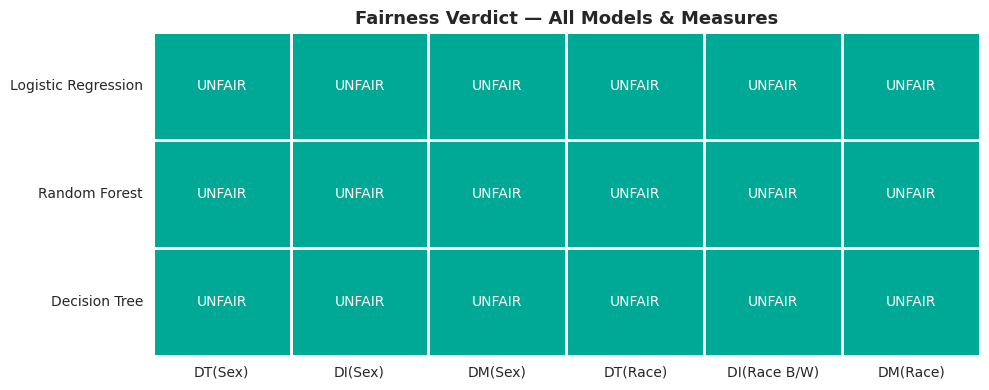

In [ ]:
# Heatmap: UNFAIR=1, FAIR=0
heat_data = verdict_df.set_index('Model').map(lambda x: 1 if x == 'UNFAIR' else 0)

fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(
    heat_data, annot=verdict_df.set_index('Model'), fmt='',
    cmap=['#00A896', '#F96167'],
    linewidths=1, linecolor='white',
    cbar=False, ax=ax
)
ax.set_title('Fairness Verdict — All Models & Measures', fontsize=13, fontweight='bold')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

---
## 11. Conclusion

**Key Findings:**

- **All three models** show significant unfairness across both `Sex` and `Race` attributes.
- **Disparate Impact** for sex is well below 0.8 for all models — meaning female candidates receive the high-income prediction at far less than 80% the rate of males, violating the four-fifths rule.
- **Disparate Treatment** gaps are large (>0.14) for all models on sex — males are predicted to earn >50K at substantially higher rates than females.
- **Disparate Mistreatment** — FNR differences for sex are very large across all models, meaning the models disproportionately miss true high-earning females.
- For **race**, Black vs White disparities are present across all three measures and all three models.
- **Random Forest** and **Decision Tree** achieve higher accuracy but do **not** reduce bias compared to Logistic Regression.
- These results confirm the UCI Adult dataset contains historical discrimination that propagates through standard ML models without any intervention.

> **No bias mitigation was applied in this notebook.** Debiasing approaches (reweighting, adversarial debiasing, threshold adjustment) are addressed in Assignment 3.